**Práctica 2. Parte 2.**
**Por Manuela Hernández y Juan Cubides**


**Acercamiento a la base de datos de arritmias cardiacas y comparación estadística** 

**Actividad**

**1. Exploración y descripción de la base de datos:**
Realice una exploración general de la base de datos proporcionada. Identifique y describa:
  •Número total de registros y sujetos.
•Tipos de arritmias o clases disponibles.
•Número de sujetos o registros pertenecientes a cada grupo.
•Número de canales disponibles y sus correspondientes derivaciones.
•Frecuencia de muestreo y duración de los registros.

Presente esta información mediante tablas y, cuando sea pertinente, gráficos que permitan visualizar la distribución de los datos entre las diferentes clases.

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import scipy.stats as stats

Total de registros: 10646
Rhythm
SB       3889
SR       1826
AFIB     1780
ST       1568
SVT       587
AF        445
SA        399
AT        121
AVNRT      16
AVRT        8
SAAWR       7
Name: count, dtype: int64
Gender
MALE      5956
FEMALE    4690
Name: count, dtype: int64
count    10646.000000
mean        59.186831
std         18.030019
min          4.000000
25%         49.000000
50%         62.000000
75%         72.000000
max         98.000000
Name: PatientAge, dtype: float64


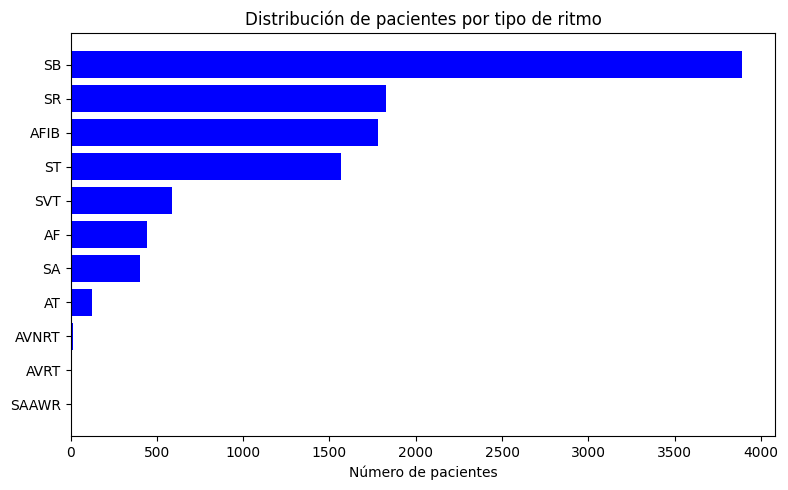

In [15]:
df = pd.read_excel("Diagnostics.xlsx")

print("Total de registros:", df.shape[0])
print(df['Rhythm'].value_counts())
print(df['Gender'].value_counts())
print(df['PatientAge'].describe())

conteo = df['Rhythm'].value_counts().sort_values()
plt.figure(figsize=(8,5))
plt.barh(conteo.index, conteo.values, color= "b")
plt.xlabel("Número de pacientes")
plt.title("Distribución de pacientes por tipo de ritmo")
plt.tight_layout()
plt.show()

**2.Visualización y caracterización de las señales:** Seleccione dos registros de dos tipos tipo de arritmia. Realice una breve consulta de esas dos arritmias y realice una visualización de las señales ECG. Analice los aspectos como la morfología, amplitud, frecuencia cardíaca y regularidad de los latidos.

**Fibrilación Auricular (AFIB):** Es la arritmia sostenida más común en la práctica clínica. Se produce por actividad eléctrica caótica y desorganizada en las aurículas, lo que hace que desaparezca la onda P (se reemplaza por ondulaciones irregulares llamadas "ondas f") y que los intervalos RR sean irregularmente irregulares (no hay un patrón fijo de distancia entre latidos). La frecuencia ventricular puede variar mucho de un latido a otro y de un paciente a otro, dependiendo de cuántos de esos impulsos caóticos logran pasar al ventrículo.

**Taquicardia Sinusal (ST):** Es un ritmo que sigue originándose de forma normal en el nodo sinoauricular (SA) — o sea, mantiene la secuencia eléctrica correcta del corazón: onda P normal antes de cada QRS, con la misma morfología de siempre — pero ocurre a una frecuencia más alta de lo normal, típicamente por encima de 100 lpm (en los datos que tenemos, el promedio es 112 lpm). Es la respuesta normal del corazón ante situaciones como ejercicio, fiebre, ansiedad, dolor, anemia, deshidratación, o algunas condiciones médicas — es decir, muchas veces es una respuesta fisiológica adecuada del cuerpo y no necesariamente indica una enfermedad del corazón en sí.

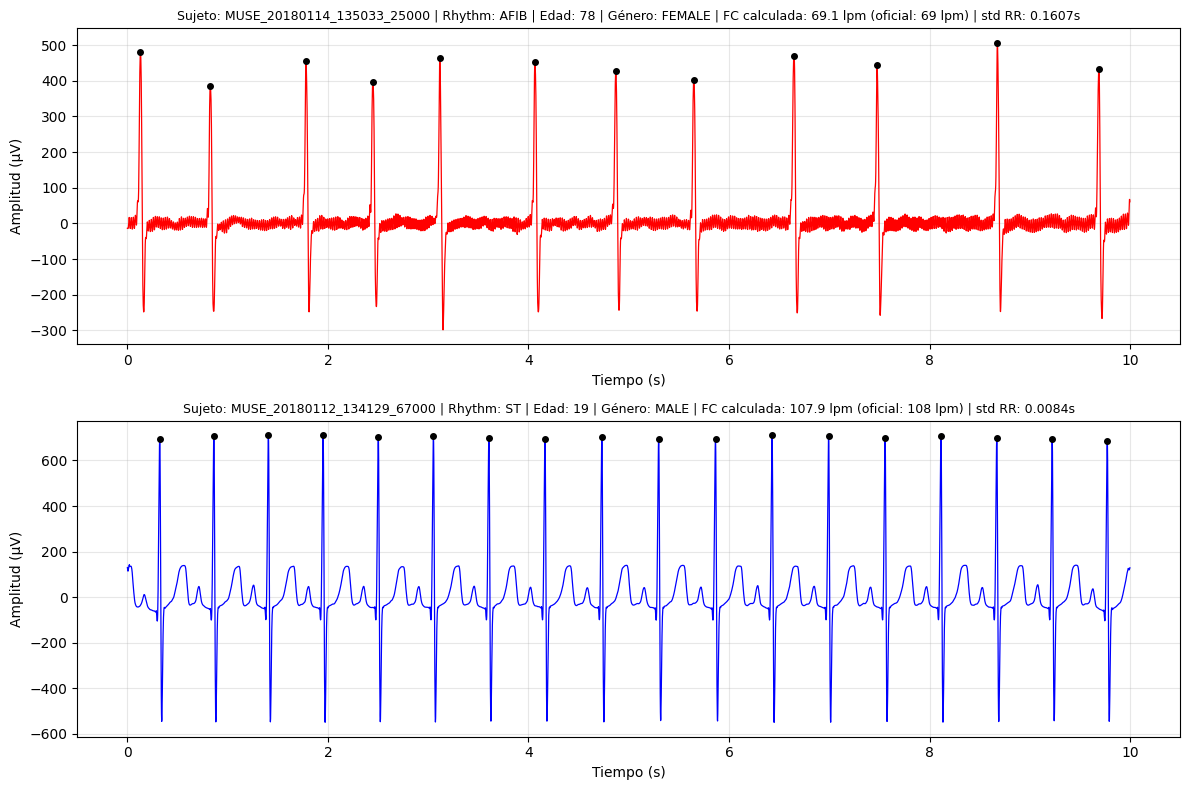

In [16]:

fs = 500 #Nos la pan en el paper

LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

diagnostics = pd.read_excel("Diagnostics.xlsx")

def cargar_señal(ruta_archivo, derivacion="II"):
    return pd.read_csv(ruta_archivo, header=None, names=LEADS)[derivacion].values

def obtener_metadata(ruta_archivo):
    nombre = Path(ruta_archivo).stem
    fila = diagnostics[diagnostics["FileName"] == nombre].reset_index(drop=True)
    return fila.loc[0]

def analizar_ritmo(señal):
    picos, _ = find_peaks(señal, distance=int(fs*0.3), prominence=(señal.max()-señal.min())*0.3)
    rr = np.diff(picos) / fs
    return picos, 60/np.mean(rr), np.std(rr)

def graficar_comparacion(rutas, colores):
    vector_tiempo = np.arange(5000) / fs  # todas las señales del dataset duran 10s a 500Hz
    plt.figure(figsize=(12,8))
    
    for i, (ruta, color) in enumerate(zip(rutas, colores), start=1):
        señal = cargar_señal(ruta)
        meta = obtener_metadata(ruta)
        picos, fc, std_rr = analizar_ritmo(señal)
        
        plt.subplot(len(rutas), 1, i)
        plt.plot(vector_tiempo, señal, color, linewidth=0.9)
        plt.plot(vector_tiempo[picos], señal[picos], 'ko', markersize=4)
        plt.title(
            f"Sujeto: {meta['FileName']} | Rhythm: {meta['Rhythm']} | "
            f"Edad: {meta['PatientAge']} | Género: {meta['Gender']} | "
            f"FC calculada: {fc:.1f} lpm (oficial: {meta['VentricularRate']} lpm) | std RR: {std_rr:.4f}s",
            fontsize=9
        )
        plt.ylabel("Amplitud (µV)")
        plt.xlabel("Tiempo (s)")
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



rutas = ["MUSE_20180114_135033_25000.csv", "MUSE_20180112_134129_67000.csv"]
graficar_comparacion(rutas, ["r-", "b-"])

**Análisis:** Al graficar las dos señales se nota una diferencia clara en la forma en que laten. En la señal de ST, los picos del corazón se ven muy parecidos entre sí y separados siempre por la misma distancia. En la señal de AFIB, en cambio, entre cada pico se ve una línea de base como si fuera ruido en vez de una curva limpia, eso es porque en la fibrilación auricular las aurículas del corazón no laten de forma organizada, entonces no aparece la onda que normalmente se ve justo antes del pico principal, que seria la onda p.

En cuanto a la frecuencia cardiaca, el registro de ST late más rápido (107.9 latidos por minuto) que el de AFIB (69.1 latidos por minuto) en este caso puntual. Pero lo más importante no es cuál es más rápida, sino qué tan regular es cada una: medimos qué tanto varía el tiempo entre un latido y el siguiente, y en AFIB esa variación es casi 19 veces mayor que en ST (0.16 segundos contra 0.008 segundos). Esto confirma con números lo que se espera clínicamente: ST es un ritmo acelerado pero ordenado, mientras que AFIB es un ritmo irregular, así su frecuencia promedio no sea especialmente alta.

Vale la pena notar que la frecuencia cardiaca calculada mediante la detección de picos R coincide casi exactamente con el valor de VentricularRate reportado oficialmente en la base de datos (69 lpm para AFIB y 108 lpm para ST), lo que valida que el método de detección utilizado es preciso.

**3.Análisis estadístico entre arritmias:**
Calcule y compare mediante un análisis descriptivo (box plots, diagramas de densidad, etc.) las siguientes características descriptivas: media, desviación estándar, valor máximo, valor mínimo, frecuencia cardíaca y el valor RMS.
Formule una hipótesis nula y una hipótesis alternativa con las arritmias escogidas anteriormente.
Antes de aplicar una prueba estadística paramétrica, compruebe los supuestos necesarios para realizar una prueba t de Student. Si los supuestos se cumplen, realice la prueba t de Student para muestras independientes con el fin de determinar si existen diferencias estadísticamente significativas entre los grupos de arritmias. Si no se cumple el supuesto de normalidad o las condiciones necesarias para utilizar la prueba t, realice un análisis no paramétrico mediante la prueba U de Mann-Whitney, apropiada para comparar dos grupos independientes.

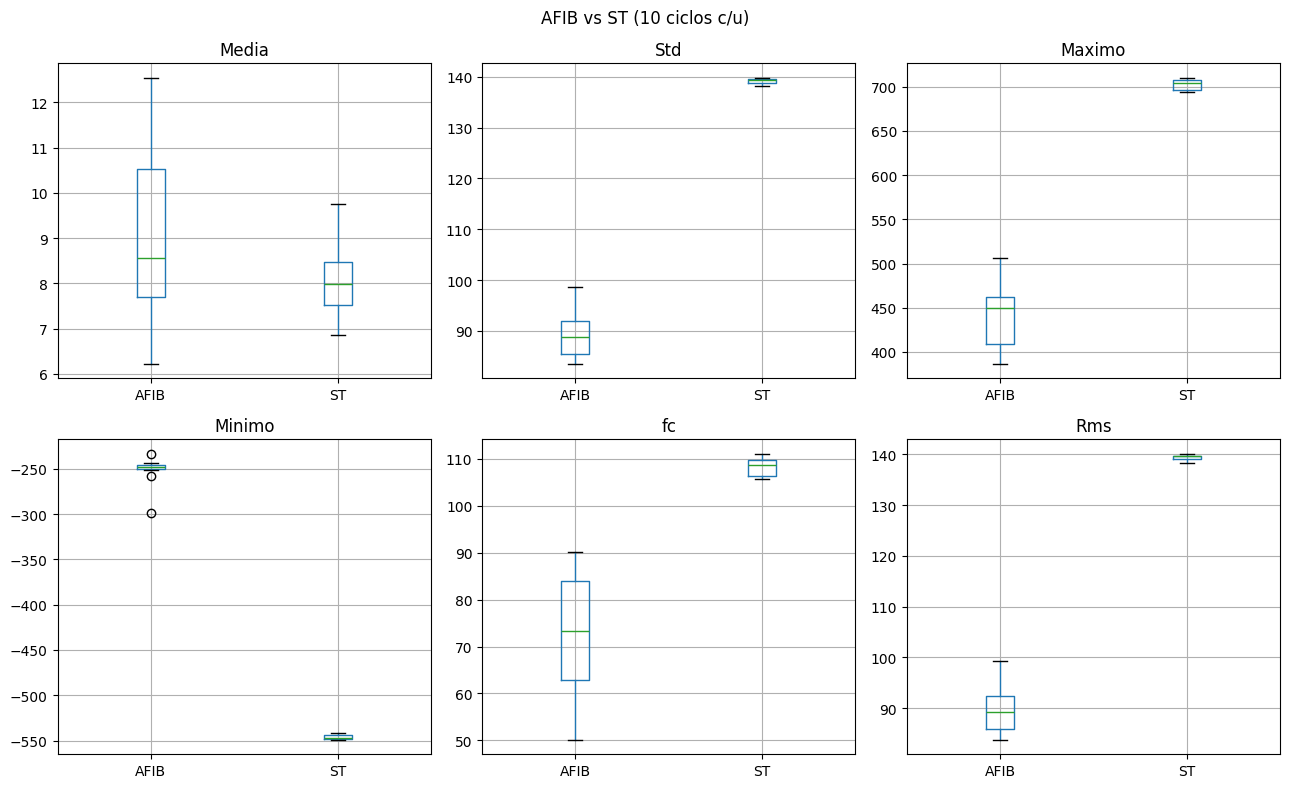

Media: U de Mann-Whitney | estadístico=60.0000 | p-valor=4.7268e-01
Std: U de Mann-Whitney | estadístico=0.0000 | p-valor=1.8267e-04
Maximo: U de Mann-Whitney | estadístico=0.0000 | p-valor=1.8267e-04
Minimo: U de Mann-Whitney | estadístico=100.0000 | p-valor=1.8267e-04
fc: U de Mann-Whitney | estadístico=0.0000 | p-valor=1.8063e-04
Rms: U de Mann-Whitney | estadístico=0.0000 | p-valor=1.8267e-04


In [17]:

def detectar_picos(señal):
    return find_peaks(señal, distance=int(fs*0.3), prominence=(señal.max()-señal.min())*0.3)[0]

#Extraer varios ciclos cardiacos alrededor de cada pico, con su FC instantánea
def extraer_ciclos(señal, n_ciclos=10, antes=0.2, despues=0.4):
    picos = detectar_picos(señal)
    m_antes, m_despues = int(antes*fs), int(despues*fs)
    validos = [p for p in picos[1:] if p-m_antes >= 0 and p+m_despues < len(señal)]
    seleccion = validos[:n_ciclos]
    
    ciclos, fc_instantanea = [], []
    for p in seleccion:
        ciclos.append(señal[p-m_antes:p+m_despues])
        idx = list(picos).index(p)
        rr = (picos[idx] - picos[idx-1]) / fs
        fc_instantanea.append(60/rr)
    return ciclos, fc_instantanea


def calcular_estadisticos_ciclos(ciclos, fc_instantanea, ruta_archivo):
    meta = obtener_metadata(ruta_archivo)
    filas = []
    for ciclo, fc in zip(ciclos, fc_instantanea):
        filas.append({
            "Media": np.mean(ciclo), "Std": np.std(ciclo),
            "Maximo": np.max(ciclo), "Minimo": np.min(ciclo),
            "fc": fc, "Rms": np.sqrt(np.mean(ciclo**2)),
            "rhythm": meta["Rhythm"], "paciente": meta["FileName"]
        })
    return pd.DataFrame(filas)


def graficar_boxplots(tabla):
    variables = ["Media", "Std", "Maximo", "Minimo", "fc", "Rms"]
    plt.figure(figsize=(13,8))
    for i, variable in enumerate(variables, start=1):
        ax = plt.subplot(2, 3, i)
        tabla.boxplot(column=variable, by="rhythm", ax=ax)
        ax.set_title(variable)
        ax.set_xlabel("")
    plt.suptitle("AFIB vs ST (10 ciclos c/u)")
    plt.tight_layout()
    plt.show()

#Comprobar supuestos y aplicar la prueba correspondiente
def comparar_grupos(grupo1, grupo2, nombre_variable):
    _, p_norm1 = stats.shapiro(grupo1)
    _, p_norm2 = stats.shapiro(grupo2)
    _, p_levene = stats.levene(grupo1, grupo2)
    normal = (p_norm1 > 0.05) and (p_norm2 > 0.05)
    homocedastico = p_levene > 0.05
    if normal and homocedastico:
        estadistico, p_valor = stats.ttest_ind(grupo1, grupo2, equal_var=True)
        prueba = "t-Student"
    else:
        estadistico, p_valor = stats.mannwhitneyu(grupo1, grupo2)
        prueba = "U de Mann-Whitney"
    print(f"{nombre_variable}: {prueba} | estadístico={estadistico:.4f} | p-valor={p_valor:.4e}")
    return prueba, estadistico, p_valor




señal_afib, señal_st = cargar_señal(rutas[0]), cargar_señal(rutas[1])
ciclos_afib, fc_afib = extraer_ciclos(señal_afib)
ciclos_st, fc_st = extraer_ciclos(señal_st)

tabla_afib = calcular_estadisticos_ciclos(ciclos_afib, fc_afib, rutas[0])
tabla_st   = calcular_estadisticos_ciclos(ciclos_st, fc_st, rutas[1])
tabla = pd.concat([tabla_afib, tabla_st])

graficar_boxplots(tabla)

for variable in ["Media","Std","Maximo","Minimo","fc","Rms"]:
    comparar_grupos(tabla_afib[variable], tabla_st[variable], variable)

**Análisis:** Para esta comparación partimos de los dos registros ya analizados en el punto 2: un paciente con fibrilación auricular (AFIB) y un paciente con taquicardia sinusal (ST). De cada uno se extrajeron 10 ciclos cardiacos individuales y, para cada ciclo, se calcularon seis estadísticos descriptivos (media, desviación estándar, valor máximo, valor mínimo, frecuencia cardiaca instantánea y RMS). Lo que buscamos responder es si estos dos ritmos, uno irregular y sin onda P organizada, el otro regular y acelerado, se reflejan también en diferencias estadísticamente significativas en estos estadísticos calculados ciclo a ciclo.

Para cada variable se planteó la misma lógica de hipótesis: la hipótesis nula (H0) supone que no hay una diferencia real entre los ciclos del paciente AFIB y los del paciente ST, es decir, que cualquier diferencia observada se debe al azar; la hipótesis alternativa (H1) supone que sí existe una diferencia real entre ambos grupos. Se trabajó con un nivel de significancia del 5% (α = 0.05).

Los box plots muestran con claridad estas diferencias entre los 10 ciclos de cada paciente. En la media, las cajas de ambos grupos se superponen bastante, sugiriendo que no hay una diferencia relevante. En cambio, en desviación estándar, máximo, mínimo, frecuencia cardiaca y RMS, las cajas están completamente separadas, sin ninguna superposición. El caso más ilustrativo es la frecuencia cardiaca: la caja de ST es pequeña y compacta (entre 105 y 111 lpm), reflejando latidos muy regulares, mientras que la caja de AFIB es mucho más alta y dispersa (entre 63 y 84 lpm, con bigotes hasta 50-90 lpm), reflejando la irregularidad característica de esta arritmia.

Esto se confirma con la prueba estadística ya que  antes de comparar los grupos se verificó, para cada variable, si cumplían normalidad (Shapiro-Wilk) y homocedasticidad (Levene). Como al menos uno de estos supuestos falló en cada variable, se usó la prueba no paramétrica U de Mann-Whitney en lugar de la t de Student. Con esta prueba se encontró diferencia significativa (p < 0.001) en desviación estándar, máximo, mínimo, frecuencia cardiaca y RMS se rechaza H0 en estas cinco variables, y ninguna diferencia significativa en la media (p = 0.47) no se rechaza H0, exactamente lo mismo que ya se observaba en los box plots.

Sin embargo, las diferencias en las variables de amplitud (std, máximo, mínimo, RMS) deben interpretarse con cautela: cada grupo proviene de un único paciente, por lo que es probable que reflejen características individuales (calibración del electrodo, contextura del paciente) más que una diferencia real entre todas las señales AFIB y todas las señales ST a nivel poblacional. La variable más confiable para concluir sobre el tipo de arritmia en sí es la frecuencia cardiaca, porque está directamente ligada a la definición clínica de cada ritmo (AFIB con frecuencia baja e irregular vs. ST con frecuencia alta y regular) y no depende de factores propios de cada paciente como sí ocurre con la amplitud de la señal.

**4.Interpretación de los resultados**
Para cada prueba estadística, reporte:
•Prueba utilizada.
•Hipótesis nula y alternativa.
•Nivel de significancia utilizado.
•
Estadístico de prueba.
•
p-valor.
•
Decisión estadística.
•
Interpretación del resultado en el contexto de las señales ECG y las arritmias.